<a href="https://colab.research.google.com/github/nihanilufar/World-Happiness-Report/blob/main/Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World Happiness Report 2021 — Exploratory Data Analysis

This notebook analyses the [World Happiness Report 2021](https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2021) dataset, covering **149 countries**. Each country is ranked by its **Ladder score** — a self-reported life evaluation on a 0–10 scale — alongside six contributing factors: GDP per capita, social support, healthy life expectancy, freedom, generosity, and perceptions of corruption.

## 1. Import Libraries

We import the three core libraries used throughout this analysis:
- **`pandas`** — loading and manipulating tabular data
- **`numpy`** — numerical computations (mean, standard deviation, etc.)
- **`matplotlib.pyplot`** — creating charts and visualisations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load and Preview the Dataset

We read the CSV into a DataFrame and display the first 5 rows. Each row is one country, with columns for its Ladder score, region, and the six WHR factors. Scores range roughly from **2.5 (least happy)** to **7.8 (happiest)**.

In [2]:
df = pd.read_csv("world-happiness-report-2021.csv")
df.head()

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


## 3. Top 10 and Bottom 10 Happiest Countries

Sorting by `Ladder score` descending reveals the happiest and least happy nations. **Nordic countries** (Finland, Denmark, Iceland) consistently dominate the top, while the lowest scores are concentrated in **Sub-Saharan Africa** and conflict-affected regions.

In [3]:
df_sorted = df.sort_values('Ladder score', ascending=False)

top10 = df_sorted.head(10)
print("Top 10 Happiest Countries:")
print(top10[['Country name', 'Ladder score']])

bottom10 = df_sorted.tail(10)
print("\nBottom 10 Happiest Countries:")
print(bottom10[['Country name', 'Ladder score']])

Top 10 Happiest Countries:
  Country name  Ladder score
0      Finland         7.842
1      Denmark         7.620
2  Switzerland         7.571
3      Iceland         7.554
4  Netherlands         7.464
5       Norway         7.392
6       Sweden         7.363
7   Luxembourg         7.324
8  New Zealand         7.277
9      Austria         7.268

Bottom 10 Happiest Countries:
    Country name  Ladder score
139      Burundi         3.775
140        Yemen         3.658
141     Tanzania         3.623
142        Haiti         3.615
143       Malawi         3.600
144      Lesotho         3.512
145     Botswana         3.467
146       Rwanda         3.415
147     Zimbabwe         3.145
148  Afghanistan         2.523


## 4. Correlation with Happiness Score

We compute the **Pearson correlation** between the Ladder score and each contributing factor. Values near **+1** indicate a strong positive relationship with happiness; values near **0 or negative** suggest little linear relationship.

> 💡 Expect `Logged GDP per capita`, `Social support`, and `Healthy life expectancy` to show the highest positive correlations, while `Perceptions of corruption` is likely negative (more corruption → lower happiness).

In [4]:
correlation = df[['Ladder score',
                   'Logged GDP per capita',
                   'Social support',
                   'Healthy life expectancy',
                   'Freedom to make life choices',
                   'Generosity',
                   'Perceptions of corruption']].corr()

print("Correlation with Happiness Score:")
print(correlation['Ladder score'])

Correlation with Happiness Score:
Ladder score                    1.000000
Logged GDP per capita           0.789760
Social support                  0.756888
Healthy life expectancy         0.768099
Freedom to make life choices    0.607753
Generosity                     -0.017799
Perceptions of corruption      -0.421140
Name: Ladder score, dtype: float64


## 5. GDP Statistics — Mean and Standard Deviation

We calculate summary statistics for `Logged GDP per capita`. Note that values are **log-transformed** (natural log of GDP per capita), not raw dollar figures. A high standard deviation indicates large economic inequality between the 149 countries surveyed.

In [5]:
mean_gdp = np.mean(df['Logged GDP per capita'])
std_gdp = np.std(df['Logged GDP per capita'])
print("Mean GDP per capita:", mean_gdp)
print("Std GDP per capita:", std_gdp)

Mean GDP per capita: 9.432208053691276
Std GDP per capita: 1.1547069779973658


## 6. Average Happiness Score by Region

Countries are grouped by `Regional indicator` and their mean Ladder scores are compared. This highlights **regional disparities** in well-being — for example, Western Europe and North America/ANZ tend to score much higher than Sub-Saharan Africa or South Asia.

In [6]:
region_happiness = df.groupby('Regional indicator')['Ladder score'].mean()

print("Average Happiness by Region:")
print(region_happiness.sort_values(ascending=False))

Average Happiness by Region:
Regional indicator
North America and ANZ                 7.128500
Western Europe                        6.914905
Central and Eastern Europe            5.984765
Latin America and Caribbean           5.908050
East Asia                             5.810333
Commonwealth of Independent States    5.467000
Southeast Asia                        5.407556
Middle East and North Africa          5.219765
Sub-Saharan Africa                    4.494472
South Asia                            4.441857
Name: Ladder score, dtype: float64


## 7. Bar Chart — Top 10 Happiest Countries

A bar chart of the 10 highest-scoring countries makes it easy to compare scores visually. Notice how closely the top nations cluster — the gap between 1st and 10th place is typically less than 0.5 points on the Ladder scale.

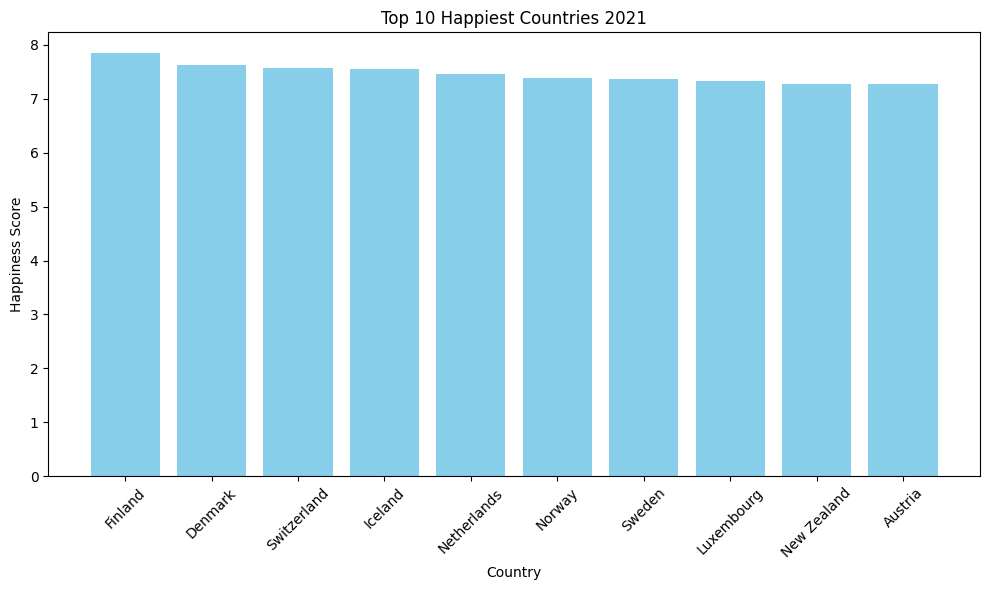

In [7]:
top10 = df.sort_values('Ladder score', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.bar(top10['Country name'], top10['Ladder score'], color='skyblue')
plt.title('Top 10 Happiest Countries 2021')
plt.xlabel('Country')
plt.ylabel('Happiness Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Scatter Plot — GDP per Capita vs. Happiness

This scatter plot examines whether wealthier countries tend to be happier. An upward trend would confirm a positive GDP–happiness relationship. Watch for **outliers**: some countries score much higher or lower than their GDP alone would predict, hinting at the influence of social and cultural factors.

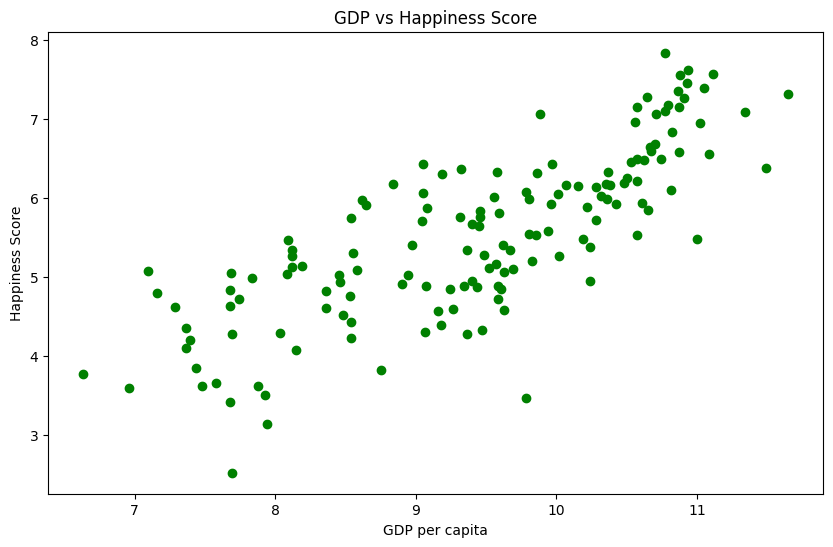

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(df['Logged GDP per capita'], df['Ladder score'], color='green')
plt.title('GDP vs Happiness Score')
plt.xlabel('GDP per capita')
plt.ylabel('Happiness Score')
plt.show()